In [3]:
import pandas as pd 
import numpy as np

In [4]:
df_90 = pd.read_csv('Datasets/spotify/dataset-of-90s.csv') 
df_00 = pd.read_csv('Datasets/spotify/dataset-of-00s.csv') 
df_10 = pd.read_csv('Datasets/spotify/dataset-of-10s.csv') 

In [5]:
df = pd.concat([
    df_90,
    df_00,
    df_10
])

In [6]:
df.head()

,track,artist,uri,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,chorus_hit,sections,target
0,Misty Roses,Astrud Gilberto,spotify:track:50RBM1j1Dw7WYmsGsWg9Tm,0.527,0.316,1,-15.769,1,0.0310,0.693000,0.00699,0.1680,0.543,116.211,158840,4,53.89523,6,0
1,Never Ever,All Saints,spotify:track:5FTz9qQ94PyUHETyAyfYZN,0.738,0.541,1,-5.485,1,0.0311,0.559000,0.00000,0.0492,0.309,134.187,387573,4,32.16853,16,1
2,Soul Sermon,Gregg Karukas,spotify:track:6m24oe3lk1UMxq9zq4iPFi,0.736,0.419,0,-10.662,1,0.0300,0.693000,0.49500,0.0809,0.265,93.982,237267,4,42.05369,9,0
3,Clarinet Marmalade - Live,Alton Purnell,spotify:track:5FOXuiLI6knVtgMUjWKj6x,0.565,0.594,5,-13.086,1,0.0646,0.655000,0.92600,0.6750,0.763,114.219,375933,4,80.99693,10,0
4,До смерті і довше - Drum & Base and Rock Remix,Skryabin,spotify:track:6CxyIPTqSPvAPXfrIZczs4,0.513,0.760,4,-10.077,1,0.0355,0.000017,0.00339,0.1530,0.961,153.166,430653,4,25.57331,20,0


In [7]:
df.shape

(17790, 19)

In [8]:
df["target"].isna().sum()

np.int64(0)

In [9]:
df["target"].value_counts(normalize=True) * 100 

target
0    50.0
1    50.0
Name: proportion, dtype: float64

In [10]:
df.drop_duplicates().shape

(17617, 19)

In [11]:
df.groupby(['track', 'artist']).size().sort_values(ascending=False)

track                                  artist              
Falling                                Julee Cruise            12
Chebika - Claudio Mate Metal Remix     Stefano Patarnello       8
Feeling Punk - Asle Remix              Todd Terry               6
Spiegel im Spiegel                     Arvo Pärt                5
Until the Day I Die                    Story Of The Year        5
                                                               ..
He's Got The Whole World In His Hands  Doc & Merle Watson       1
He's Mine                              MoKenStef                1
Head (She's Just a...) [Rock Version]  Atom And His Package     1
Head Home                              Midlake                  1
雏鹰                                     窒息                       1
Length: 17362, dtype: int64

# Features

In [12]:
df.head()

,track,artist,uri,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,chorus_hit,sections,target
0,Misty Roses,Astrud Gilberto,spotify:track:50RBM1j1Dw7WYmsGsWg9Tm,0.527,0.316,1,-15.769,1,0.0310,0.693000,0.00699,0.1680,0.543,116.211,158840,4,53.89523,6,0
1,Never Ever,All Saints,spotify:track:5FTz9qQ94PyUHETyAyfYZN,0.738,0.541,1,-5.485,1,0.0311,0.559000,0.00000,0.0492,0.309,134.187,387573,4,32.16853,16,1
2,Soul Sermon,Gregg Karukas,spotify:track:6m24oe3lk1UMxq9zq4iPFi,0.736,0.419,0,-10.662,1,0.0300,0.693000,0.49500,0.0809,0.265,93.982,237267,4,42.05369,9,0
3,Clarinet Marmalade - Live,Alton Purnell,spotify:track:5FOXuiLI6knVtgMUjWKj6x,0.565,0.594,5,-13.086,1,0.0646,0.655000,0.92600,0.6750,0.763,114.219,375933,4,80.99693,10,0
4,До смерті і довше - Drum & Base and Rock Remix,Skryabin,spotify:track:6CxyIPTqSPvAPXfrIZczs4,0.513,0.760,4,-10.077,1,0.0355,0.000017,0.00339,0.1530,0.961,153.166,430653,4,25.57331,20,0


In [13]:
df.dtypes

track                object
artist               object
uri                  object
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
duration_ms           int64
time_signature        int64
chorus_hit          float64
sections              int64
target                int64
dtype: object

In [14]:
df.describe()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,chorus_hit,sections,target
count,17790.000000,17790.000000,17790.000000,17790.000000,17790.000000,17790.000000,17790.000000,17790.000000,17790.000000,17790.000000,17790.00000,1.779000e+04,17790.000000,17790.000000,17790.000000,17790.000000
mean,0.559440,0.656260,5.274817,-8.364215,0.652839,0.088697,0.239137,0.158870,0.196671,0.485603,121.01916,2.498424e+05,3.922709,40.922312,10.812760,0.500000
std,0.187818,0.246307,3.562926,5.305503,0.476081,0.092549,0.307601,0.308722,0.167451,0.255318,29.88302,1.117143e+05,0.379259,19.909212,4.738156,0.500014
min,0.057600,0.000251,0.000000,-49.253000,0.000000,0.022000,0.000000,0.000000,0.013000,0.000000,34.53500,1.592000e+04,0.000000,0.000000,1.000000,0.000000
25%,0.437000,0.505000,2.000000,-9.911000,0.000000,0.035700,0.008810,0.000000,0.093600,0.278000,97.16900,2.000468e+05,4.000000,27.884680,8.000000,0.000000
50%,0.577000,0.700000,5.000000,-6.902000,1.000000,0.050400,0.081600,0.000046,0.128000,0.487000,119.87800,2.334570e+05,4.000000,36.258675,10.000000,0.500000
75%,0.697000,0.857000,8.000000,-5.028000,1.000000,0.096700,0.377000,0.061500,0.257000,0.690000,140.00075,2.766830e+05,4.000000,48.306250,12.000000,1.000000
max,0.986000,0.999000,11.000000,1.137000,1.000000,0.956000,0.996000,0.998000,0.992000,0.996000,217.94300,4.170227e+06,5.000000,262.615400,169.000000,1.000000


In [15]:
import seaborn as sns 

In [16]:
sns.pairplot(df, hue='target')

KeyboardInterrupt: 

Error in callback <function flush_figures at 0x155f6c040> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

## Separação dos Dados

In [ ]:
df.columns

Index(['track', 'artist', 'uri', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'duration_ms', 'time_signature', 'chorus_hit',
       'sections', 'target'],
      dtype='object')

In [ ]:
features = ["danceability", "energy", "key", "loudness", "mode", "speechiness", "acousticness", "instrumentalness", "liveness", "valence", "tempo", "duration_ms"]
target = "target"

In [ ]:
X = df[features]
y = df[target]

In [ ]:
y.head()

0    0
1    1
2    0
3    0
4    0
Name: target, dtype: int64

In [ ]:
X.shape

(17790, 12)

In [ ]:
df.drop(["target", "track", "artist", "uri"], axis=1)

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,chorus_hit,sections
0,0.527,0.316,1,-15.769,1,0.0310,0.693000,0.006990,0.1680,0.5430,116.211,158840,4,53.89523,6
1,0.738,0.541,1,-5.485,1,0.0311,0.559000,0.000000,0.0492,0.3090,134.187,387573,4,32.16853,16
2,0.736,0.419,0,-10.662,1,0.0300,0.693000,0.495000,0.0809,0.2650,93.982,237267,4,42.05369,9
3,0.565,0.594,5,-13.086,1,0.0646,0.655000,0.926000,0.6750,0.7630,114.219,375933,4,80.99693,10
4,0.513,0.760,4,-10.077,1,0.0355,0.000017,0.003390,0.1530,0.9610,153.166,430653,4,25.57331,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6393,0.172,0.358,9,-14.430,1,0.0342,0.886000,0.966000,0.3140,0.0361,72.272,150857,4,24.30824,7
6394,0.910,0.366,1,-9.954,1,0.0941,0.099600,0.000000,0.2610,0.7400,119.985,152000,4,32.53856,8
6395,0.719,0.804,10,-4.581,1,0.0355,0.013200,0.000003,0.1390,0.6050,119.999,227760,4,20.73371,7
6396,0.600,0.177,7,-16.070,1,0.0561,0.989000,0.868000,0.1490,0.5600,120.030,213387,4,21.65301,14


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=True)

In [ ]:
print("Features X_train", X_train.shape)
print("Features X_test", X_test.shape)

print("Target y_train", y_train.shape)
print("Target y_test", y_test.shape)

Features X_train (12453, 12)
Features X_test (5337, 12)
Target y_train (12453,)
Target y_test (5337,)


In [ ]:
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=42, random_state=42)

In [ ]:
print(X_val.shape)
print(X_test.shape)

(5295, 12)
(42, 12)


## Métricas de avaliação

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
y_true = [0, 1, 0, 1, 1, 1, 0 , 0, 1, 0]
y_pred = [0, 1, 1, 0, 1, 1, 0, 0, 1, 1]

In [ ]:
acuracia = accuracy_score(y_true, y_pred)
print(acuracia)

precisao = precision_score(y_true, y_pred)
print(precisao)

recall = recall_score(y_true, y_pred)
print(recall)

f1 = f1_score(y_true, y_pred)
print(f1)


0.7
0.6666666666666666
0.8
0.7272727272727273


In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)

<Axes: >

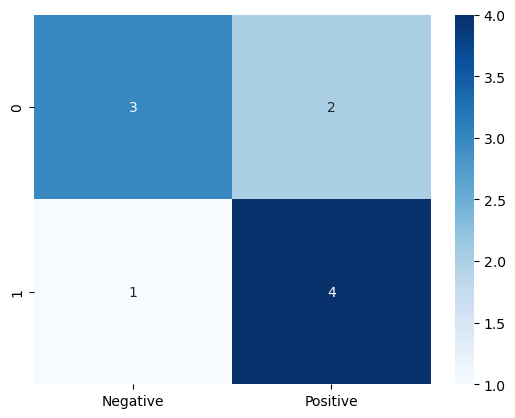

In [ ]:
sns.heatmap(cm, cmap="Blues", annot=True, xticklabels=["Negative", "Positive"])

Text(0.5, 1.0, 'Confusion Matrix')

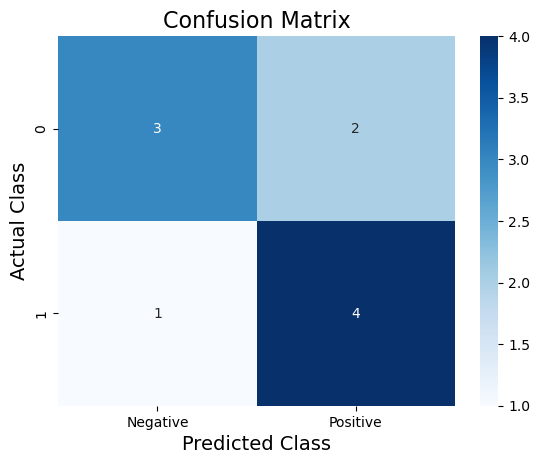

In [ ]:
ax = sns.heatmap(cm, cmap="Blues", annot=True, xticklabels=["Negative", "Positive"])

ax.set_xlabel("Predicted Class", fontsize=14)
ax.set_ylabel("Actual Class", fontsize=14)
ax.set_title("Confusion Matrix", fontsize=16)

## Regressão Logística

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=features)
X_train.head()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,0.834987,0.515394,1.000000,0.897291,0.0,0.026078,0.348394,0.001563,0.105209,0.401606,0.354465,0.058111
1,0.429465,0.636545,0.000000,0.930997,1.0,0.004526,0.352410,0.000007,0.100102,0.238956,0.624715,0.048778
2,0.328085,0.408260,0.818182,0.773043,0.0,0.005711,0.185743,0.000003,0.102145,0.272088,0.299463,0.039804
3,0.721743,0.974969,0.363636,0.955355,0.0,0.047953,0.103414,0.000533,0.165475,0.968876,0.255164,0.052787
4,0.724978,0.679599,0.636364,0.832422,0.0,0.072091,0.286145,0.000041,0.064147,0.815261,0.394290,0.067499


In [ ]:
X_test = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)

In [ ]:
model

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [ ]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
y_pred

array([0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0])

In [ ]:
pd.Series(y_pred).value_counts(normalize=True)

1    0.571429
0    0.428571
Name: proportion, dtype: float64

In [ ]:
accuracy_score(y_test, y_pred)

0.7857142857142857

In [ ]:
from sklearn.metrics import classification_report


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.70      0.78        23
           1       0.71      0.89      0.79        19

    accuracy                           0.79        42
   macro avg       0.80      0.80      0.79        42
weighted avg       0.81      0.79      0.79        42



# K-NN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
model = KNeighborsClassifier(n_neighbors=3)

In [ ]:
model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.70      0.78        23
           1       0.71      0.89      0.79        19

    accuracy                           0.79        42
   macro avg       0.80      0.80      0.79        42
weighted avg       0.81      0.79      0.79        42



## Arvore de Decisão

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.78      0.73        23
           1       0.69      0.58      0.63        19

    accuracy                           0.69        42
   macro avg       0.69      0.68      0.68        42
weighted avg       0.69      0.69      0.69        42



In [ ]:
model = DecisionTreeClassifier(random_state=42, criterion="entropy")

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.83      0.83        23
           1       0.79      0.79      0.79        19

    accuracy                           0.81        42
   macro avg       0.81      0.81      0.81        42
weighted avg       0.81      0.81      0.81        42



In [ ]:
y_pred_train = model.predict(X_train)
print(classification_report(y_train, y_pred_train))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6165
           1       1.00      1.00      1.00      6288

    accuracy                           1.00     12453
   macro avg       1.00      1.00      1.00     12453
weighted avg       1.00      1.00      1.00     12453



In [ ]:
model = DecisionTreeClassifier(random_state=42, criterion="entropy", max_depth=7)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.65      0.77        23
           1       0.69      0.95      0.80        19

    accuracy                           0.79        42
   macro avg       0.81      0.80      0.78        42
weighted avg       0.83      0.79      0.78        42



In [ ]:
y_pred_train = model.predict(X_train)
print(classification_report(y_train, y_pred_train))

              precision    recall  f1-score   support

           0       0.90      0.75      0.82      6165
           1       0.79      0.92      0.85      6288

    accuracy                           0.83     12453
   macro avg       0.84      0.83      0.83     12453
weighted avg       0.84      0.83      0.83     12453



## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.70      0.76        23
           1       0.70      0.84      0.76        19

    accuracy                           0.76        42
   macro avg       0.77      0.77      0.76        42
weighted avg       0.78      0.76      0.76        42



In [ ]:
model = RandomForestClassifier(random_state=42, n_estimators=200)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))



              precision    recall  f1-score   support

           0       0.85      0.74      0.79        23
           1       0.73      0.84      0.78        19

    accuracy                           0.79        42
   macro avg       0.79      0.79      0.79        42
weighted avg       0.79      0.79      0.79        42



## Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
model = GradientBoostingClassifier(random_state=42)
model.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [ ]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.74      0.79        23
           1       0.73      0.84      0.78        19

    accuracy                           0.79        42
   macro avg       0.79      0.79      0.79        42
weighted avg       0.79      0.79      0.79        42



In [ ]:
model = GradientBoostingClassifier(random_state=42, n_estimators=200)
model.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [ ]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.74      0.79        23
           1       0.73      0.84      0.78        19

    accuracy                           0.79        42
   macro avg       0.79      0.79      0.79        42
weighted avg       0.79      0.79      0.79        42



## Comparando os Modelos

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "K-NN": KNeighborsClassifier(n_neighbors=3),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Neural Network": MLPClassifier(random_state=42)
}



In [ ]:
results_mean = []
results_std = []
results_names = []


for model_name, model in models.items():
    print(model_name, model)

    cv_score = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
    results_mean.append(cv_score.mean())
    results_std.append(cv_score.std())
    results_names.append(model_name)

Logistic Regression LogisticRegression(random_state=42)
K-NN KNeighborsClassifier(n_neighbors=3)
Decision Tree DecisionTreeClassifier(random_state=42)
Random Forest RandomForestClassifier(random_state=42)
Gradient Boosting GradientBoostingClassifier(random_state=42)
Neural Network MLPClassifier(random_state=42)


c:\Users\guilh\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\guilh\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\guilh\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\guilh\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\guilh\anaconda3\Lib\site-packages\sklearn\neural_network\_multi

In [ ]:
df_results = pd.DataFrame(
    {
        "Modelo": results_names,
        "Acurácia Média": results_mean, 
        "Acurácia Std(Desvio Padrão)": results_std
    }
)

In [ ]:
df_results

,Modelo,Acurácia Média,Acurácia Std(Desvio Padrão)
0,Logistic Regression,0.797078,0.004546
1,K-NN,0.776038,0.006825
2,Decision Tree,0.757488,0.005096
3,Random Forest,0.837148,0.004247
4,Gradient Boosting,0.834899,0.005138
5,Neural Network,0.822052,0.008118


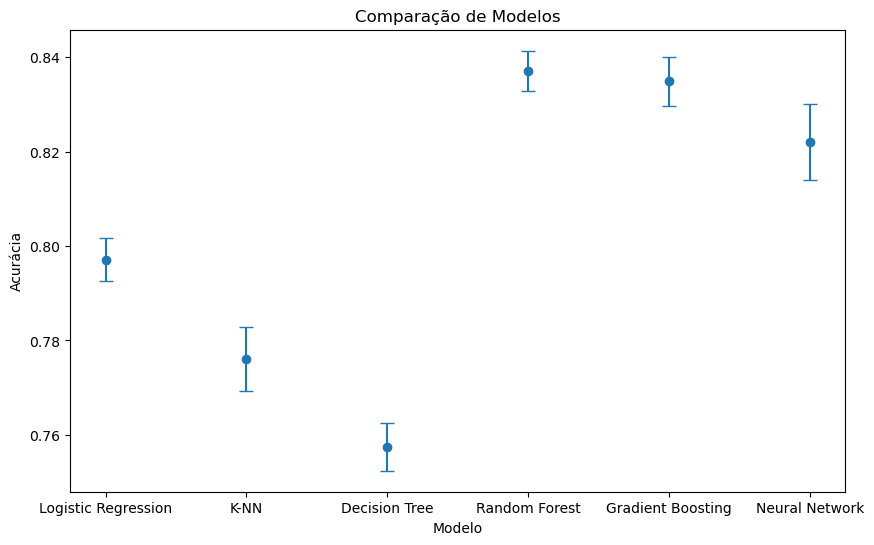

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.errorbar(df_results["Modelo"], df_results["Acurácia Média"], yerr=df_results["Acurácia Std(Desvio Padrão)"], fmt="o", capsize=5)
plt.ylabel("Acurácia")
plt.xlabel("Modelo")
plt.title("Comparação de Modelos")
plt.show()

## Tuning de Hiperparametros

In [ ]:
k_list = [1, 3, 5, 7, 9,15, 21, 25]

In [ ]:
results = []
for k in k_list: 
    scores = cross_val_score(KNeighborsClassifier(n_neighbors=k), X_train, y_train, cv=5, scoring="accuracy")
    results.append({
        "k": k,
        "accuracia": scores.mean(),
    })

df_results = pd.DataFrame(results)

In [ ]:
results

[{'k': 1, 'accuracia': np.float64(0.7449607986341189)},
 {'k': 3, 'accuracia': np.float64(0.7760376229929754)},
 {'k': 5, 'accuracia': np.float64(0.7887253872978868)},
 {'k': 7, 'accuracia': np.float64(0.7937846609239043)},
 {'k': 9, 'accuracia': np.float64(0.7954709887321264)},
 {'k': 15, 'accuracia': np.float64(0.7993256043040085)},
 {'k': 21, 'accuracia': np.float64(0.7974787306592892)},
 {'k': 25, 'accuracia': np.float64(0.7965955834578781)}]

In [ ]:
df_results_knn = pd.DataFrame(results)

In [ ]:
df_results_knn

,k,accuracia
0,1,0.744961
1,3,0.776038
2,5,0.788725
3,7,0.793785
4,9,0.795471
5,15,0.799326
6,21,0.797479
7,25,0.796596


<Axes: xlabel='k', ylabel='accuracia'>

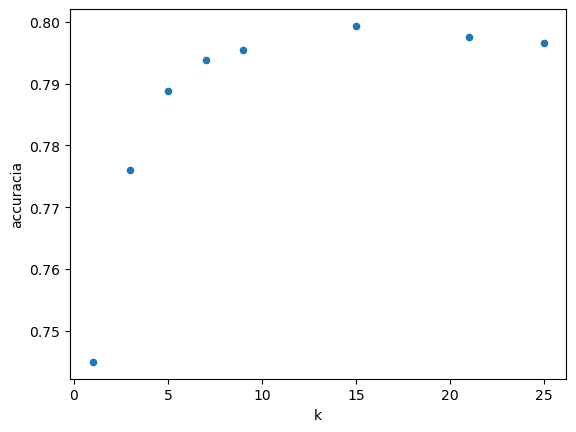

In [ ]:
df_results_knn.plot(x="k", y="accuracia", kind="scatter")

In [ ]:
criterion_list = ["gini", "entropy"]
max_depth_list = [None, 3, 5, 7, 10, 15]
min_samples_split_list = [2, 6, 20]

In [ ]:
count = 0 
for criterion in criterion_list: 
    for max_depth in max_depth_list: 
        for min_samples_split in min_samples_split_list: 
            count += 1 
            print(f"Modelo {count}: Criterion: {criterion}, Max Depth: {max_depth}, Min Samples Split: {min_samples_split}")
            count = count + 1 
    print("Count: ", count)

Modelo 1: Criterion: gini, Max Depth: None, Min Samples Split: 2
Modelo 3: Criterion: gini, Max Depth: None, Min Samples Split: 6
Modelo 5: Criterion: gini, Max Depth: None, Min Samples Split: 20
Modelo 7: Criterion: gini, Max Depth: 3, Min Samples Split: 2
Modelo 9: Criterion: gini, Max Depth: 3, Min Samples Split: 6
Modelo 11: Criterion: gini, Max Depth: 3, Min Samples Split: 20
Modelo 13: Criterion: gini, Max Depth: 5, Min Samples Split: 2
Modelo 15: Criterion: gini, Max Depth: 5, Min Samples Split: 6
Modelo 17: Criterion: gini, Max Depth: 5, Min Samples Split: 20
Modelo 19: Criterion: gini, Max Depth: 7, Min Samples Split: 2
Modelo 21: Criterion: gini, Max Depth: 7, Min Samples Split: 6
Modelo 23: Criterion: gini, Max Depth: 7, Min Samples Split: 20
Modelo 25: Criterion: gini, Max Depth: 10, Min Samples Split: 2
Modelo 27: Criterion: gini, Max Depth: 10, Min Samples Split: 6
Modelo 29: Criterion: gini, Max Depth: 10, Min Samples Split: 20
Modelo 31: Criterion: gini, Max Depth: 15, 

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

In [ ]:
params_grid = { 
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 3, 5, 7, 10, 15],
    "min_samples_split": [2, 6, 20]
}

model = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(
    estimator=model,
    param_grid=params_grid,
    cv=5,
    scoring="accuracy"
)



In [ ]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [None, 3, ...], 'min_samples_split': [2, 6, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is disp

In [ ]:
from scipy.stats import uniform, randint

In [ ]:

params_dist_gb = {
    "n_estimators": randint(50, 500),
    "subsample": uniform(0.5, 1.0),
    "max_depth": randint(3, 10),
    "min_samples_split": randint(2, 20)
}

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier
model = GradientBoostingClassifier(random_state=42)

In [ ]:
random_search = RandomizedSearchCV(model, params_dist_gb, n_iter=20, cv=20, scoring="accuracy", random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

c:\Users\guilh\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
180 fits failed out of a total of 400.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\guilh\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\guilh\anaconda3\Lib\site-packages\sklearn\base.py", line 1329, in wrapper
    estimator._validate_params()
  File "c:\Users\guilh\anaconda3\Lib\site-packages\sklearn\base.py", line 492, in _validate_params
    validate_parameter_constraints(
  File "c:\Users\guilh\anaconda3\Lib\site-package

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': <scipy.stats....001E48C18CCE0>, 'min_samples_split': <scipy.stats....001E48C18D9A0>, 'n_estimators': <scipy.stats....001E48C18D1F0>, 'subsample': <scipy.stats....001E48BF648C0>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for 

## Modelos Interpretáveis

In [ ]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
from sklearn.metrics import classification_report

In [ ]:
dataset = load_breast_cancer()

In [ ]:
X = dataset.data 
y = dataset.target

In [ ]:
X = pd.DataFrame(X, columns=dataset.feature_names)
X

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [ ]:
y = pd.Series(y)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=True)

In [ ]:
model = DecisionTreeClassifier(max_depth=5)
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.95      0.94        63
           1       0.97      0.95      0.96       108

    accuracy                           0.95       171
   macro avg       0.95      0.95      0.95       171
weighted avg       0.95      0.95      0.95       171



In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

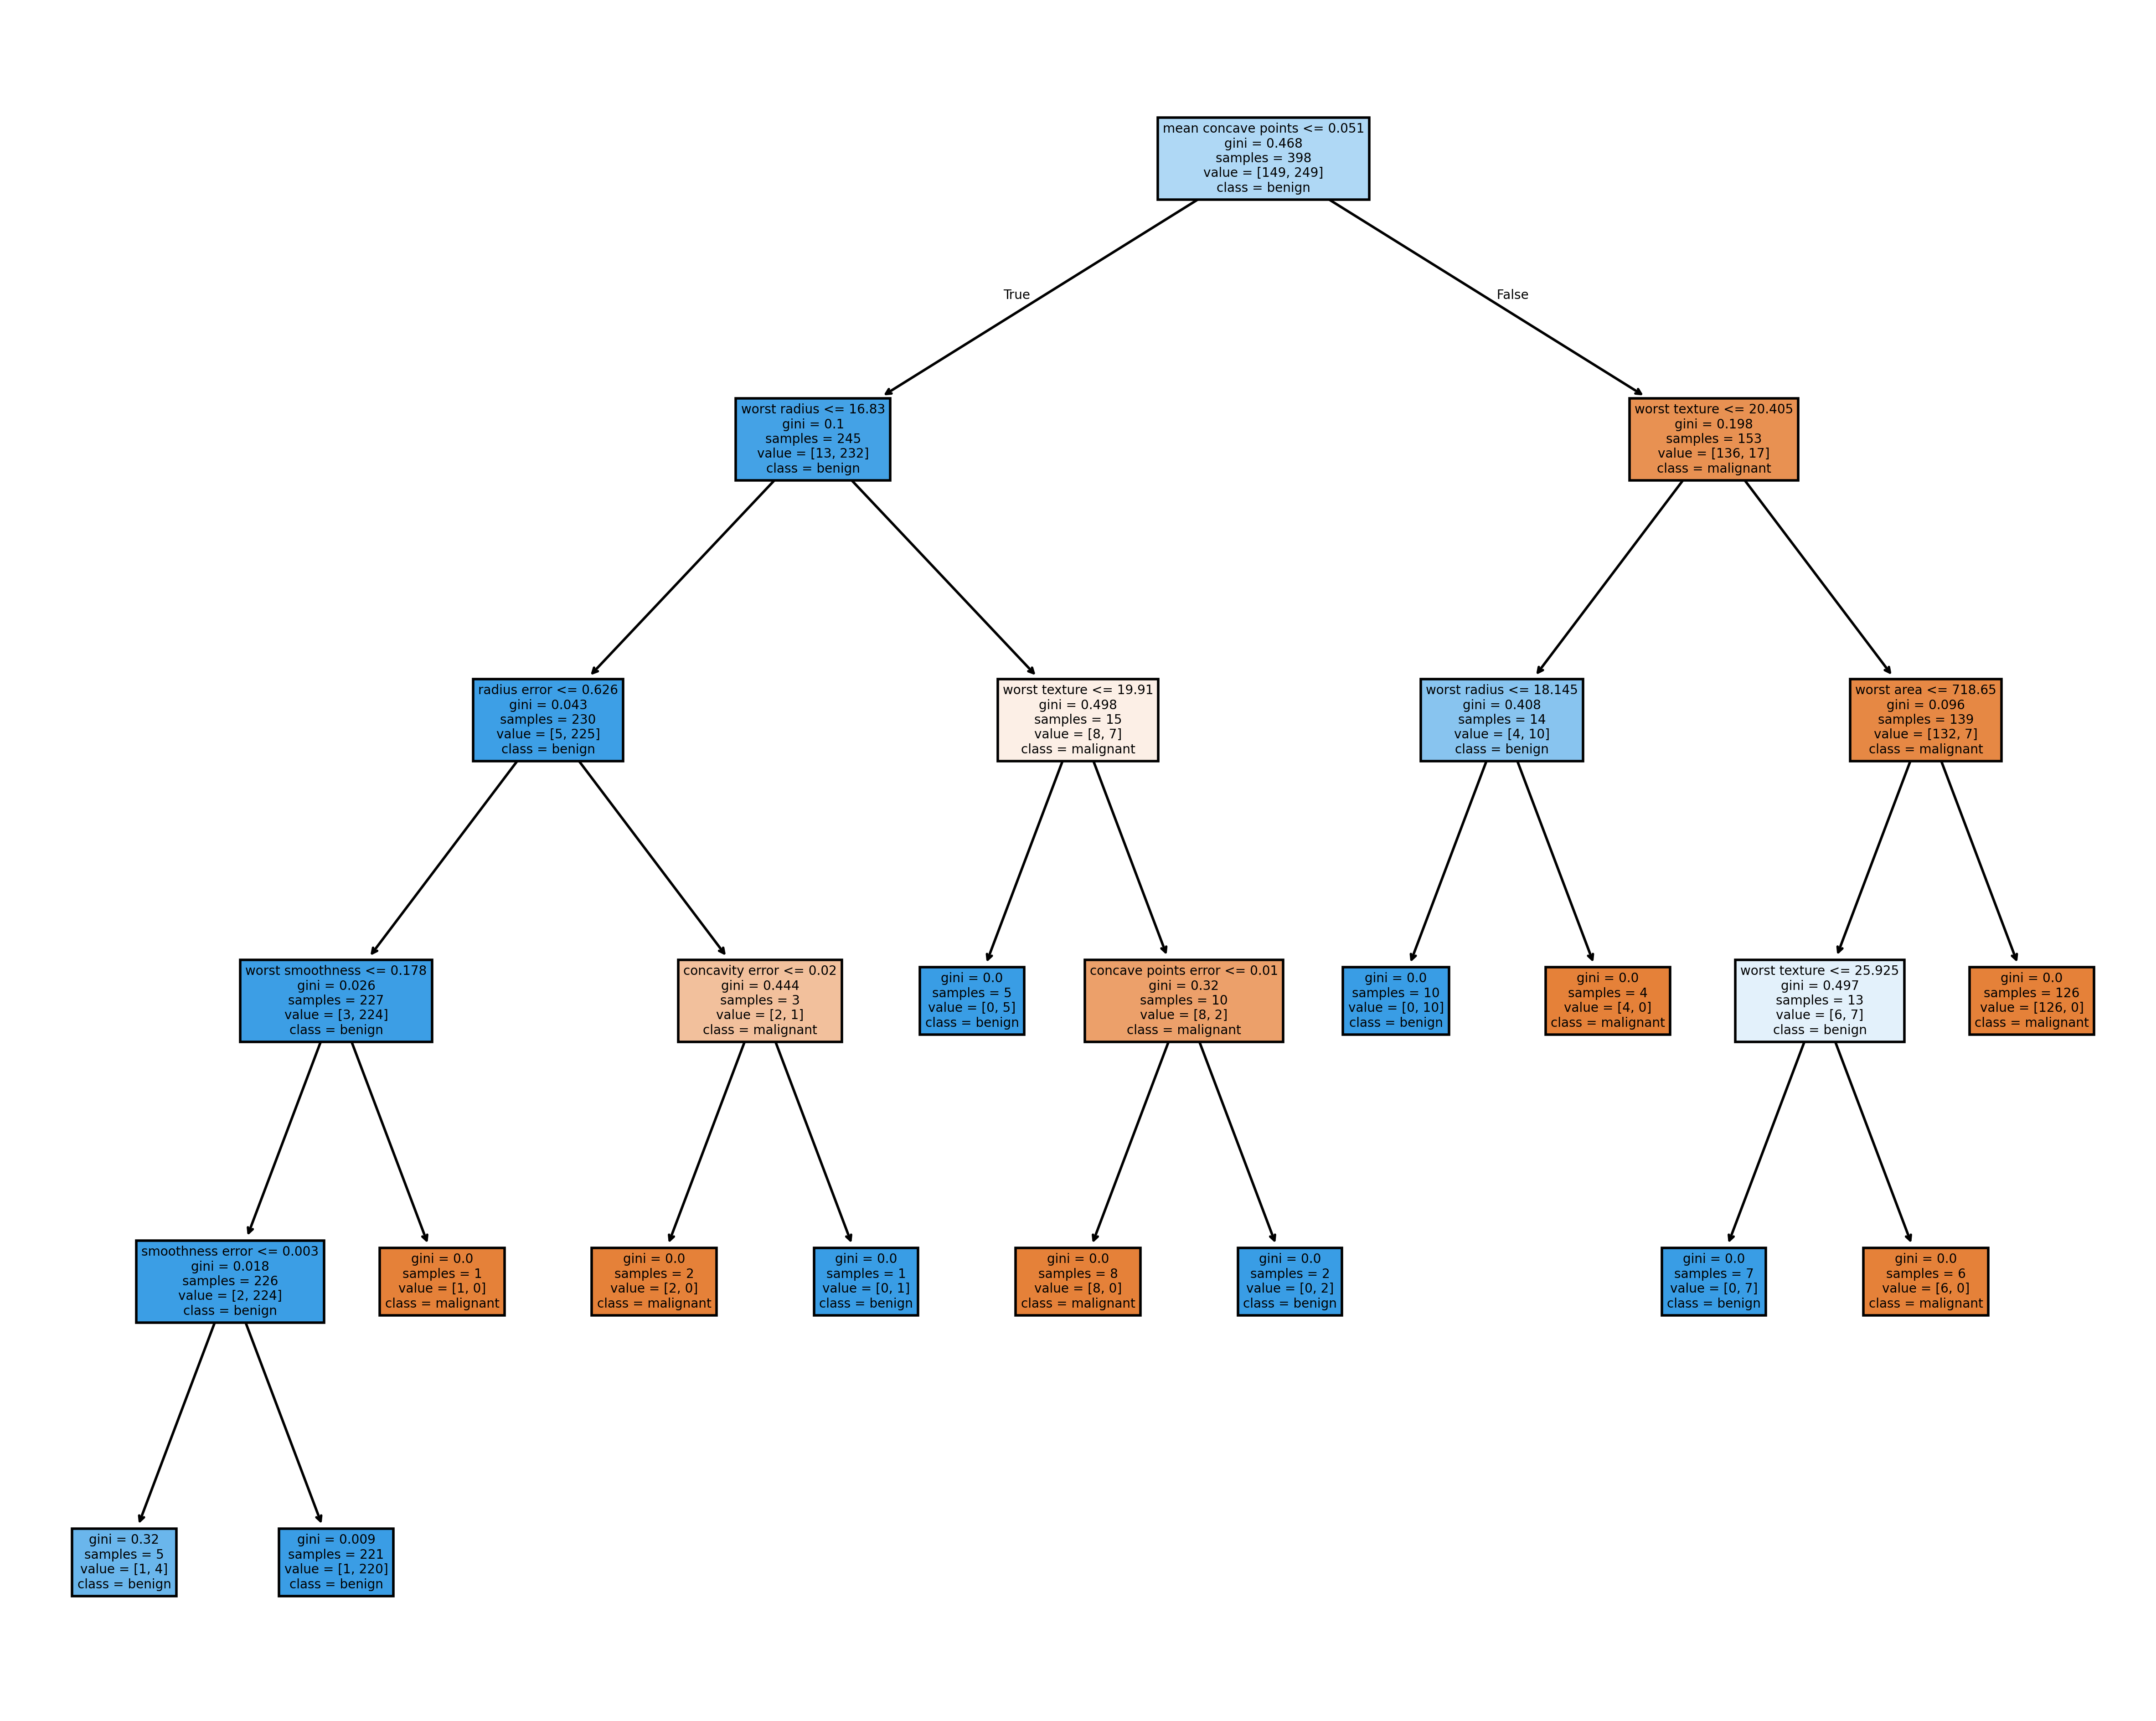

In [ ]:
plt.figure(figsize=(15, 12), dpi=400)
plot_tree(model, filled=True, feature_names=dataset.feature_names, class_names=dataset.target_names)
plt.show()

## Modelos Black Box

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
model = GradientBoostingClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.94      0.94        63
           1       0.96      0.97      0.97       108

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



In [ ]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.98      0.94      0.96        63
           1       0.96      0.99      0.98       108

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



In [20]:
df_gym = pd.read_csv('./Datasets/gym_members_exercise_tracking.csv')

In [21]:
df_gym.shape

(973, 15)

In [22]:
df_gym.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


<Axes: xlabel='Session_Duration (hours)', ylabel='Calories_Burned'>

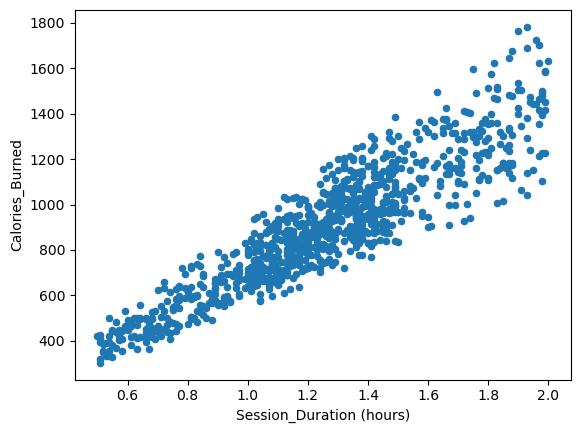

In [23]:
df_gym.plot(x="Session_Duration (hours)", y='Calories_Burned', kind='scatter')

In [24]:
X = df_gym[["Session_Duration (hours)"]]
y = df_gym[["Calories_Burned"]]

In [28]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [25]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [26]:
pred = model.predict(X)

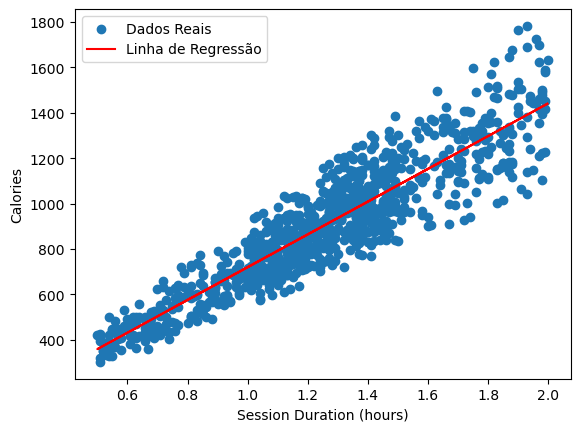

In [29]:
plt.scatter(x=X['Session_Duration (hours)'], y=y, label='Dados Reais')
plt.plot(X['Session_Duration (hours)'], pred, label='Linha de Regressão', color='red')
plt.ylabel("Calories")
plt.xlabel("Session Duration (hours)")
plt.legend()
plt.show()

In [30]:
residuals = y - pred

In [31]:
residuals # Se for positivo indica valores menores, se for negativo valores maiores

,Calories_Burned
0,94.628092
1,-53.875362
2,-122.736019
3,107.592709
4,95.503409
...,...
968,232.242414
969,265.381757
970,-311.025489
971,90.481841


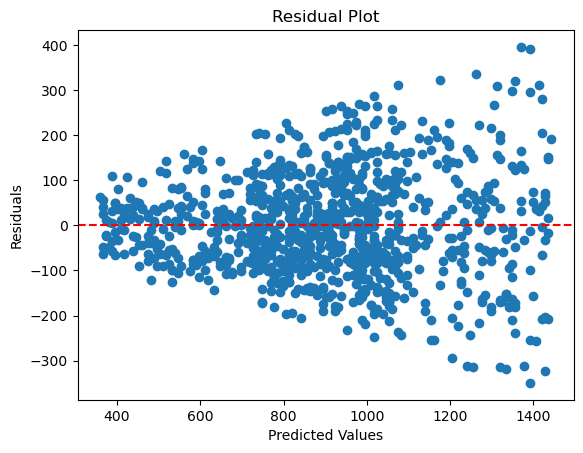

In [32]:
plt.scatter(pred, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.ylabel("Residuals")
plt.xlabel("Predicted Values")
plt.title("Residual Plot")
plt.show()

In [33]:
from sklearn.model_selection import train_test_split

In [34]:
X = df_gym.drop("Calories_Burned", axis=1)
y = df_gym['Calories_Burned']

In [35]:
from sklearn.model_selection import train_test_split

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [37]:
X_train.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
967,20,Male,55.0,1.60,172,168,67,1.12,Yoga,24.0,3.2,4,2,21.48
365,39,Female,60.6,1.65,162,167,63,0.92,HIIT,27.6,1.7,3,1,22.26
559,54,Female,75.6,1.72,194,154,60,0.97,Cardio,26.4,1.9,3,1,25.55
33,24,Female,58.9,1.51,187,157,68,1.04,Cardio,31.7,2.5,2,1,25.83
31,20,Female,65.4,1.52,185,127,50,1.03,Yoga,28.0,2.2,4,2,28.31


In [38]:
X_train["Workout_Type"].value_counts()

Workout_Type
Strength    211
Cardio      209
Yoga        179
HIIT        179
Name: count, dtype: int64

In [39]:
from sklearn.preprocessing import OneHotEncoder

In [40]:
encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
encoder.fit(X_train[["Workout_Type", "Gender"]])

X_train_categorical_columns = encoder.transform(X_train[["Workout_Type", "Gender"]])
X_test_categorical_columns = encoder.transform(X_test[["Workout_Type", "Gender"]])

In [41]:
X_train = pd.concat([X_train.drop(['Workout_Type', 'Gender'], axis=1), X_train_categorical_columns], axis=1)

In [42]:
X_test = pd.concat([X_test.drop(["Workout_Type", "Gender"], axis=1), X_test_categorical_columns], axis=1)

In [43]:
model = LinearRegression()
model.fit(X_train[['Session_Duration (hours)']], y_train)

y_pred = model.predict(X_test[["Session_Duration (hours)"]])

In [44]:
residuals = y_test - y_pred

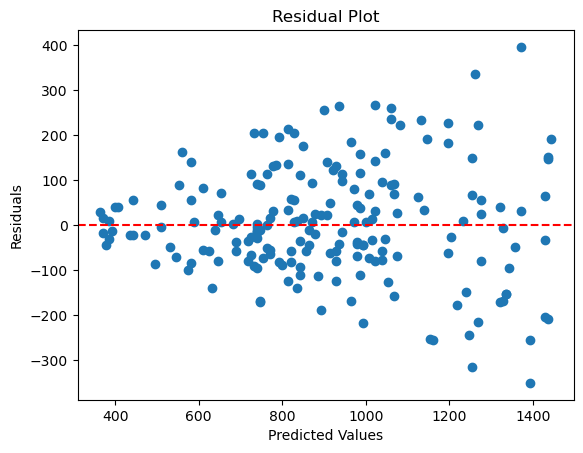

In [45]:
import matplotlib.pyplot as plt
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [46]:
model.intercept_

np.float64(-5.807918457492633)

In [47]:
model.coef_

array([724.41697682])

In [48]:
len(model.coef_)

1

In [49]:
x = X_test.iloc[0]

In [50]:
sum(model.coef_ * x) + model.intercept_

np.float64(389679.81642221654)

In [51]:
y_pred[0]

np.float64(906.9574723354531)

In [52]:
# O modelo foi treinado só com 'Session_Duration (hours)', então coef_ tem 1 elemento
features_usadas = ['Session_Duration (hours)']
df_coef = pd.DataFrame({
    "Features": features_usadas,
    "Coeficientes": model.coef_
})
df_coef

,Features,Coeficientes
0,Session_Duration (hours),724.416977


In [53]:
df_coef["Coeficiente_Absoluto"] = df_coef['Coeficientes'].abs()

<Axes: ylabel='Features'>

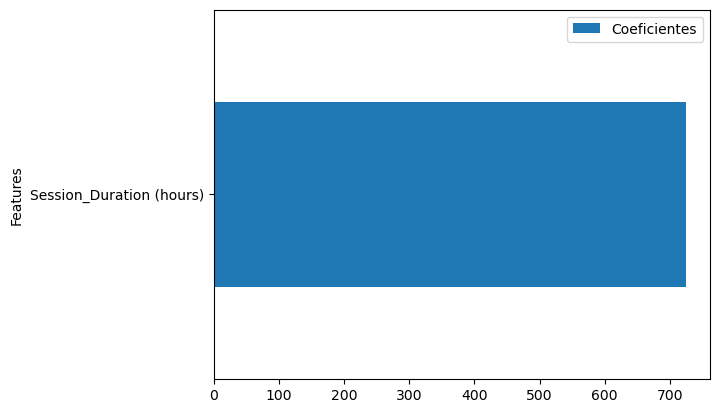

In [54]:
df_coef.sort_values("Coeficiente_Absoluto", ascending=False).plot(kind="barh", x="Features", y="Coeficientes")

<Axes: ylabel='Frequency'>

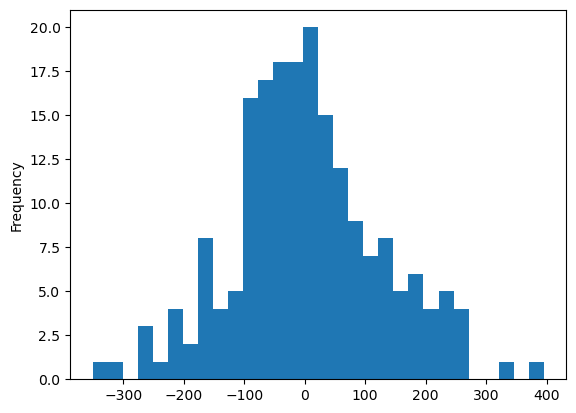

In [56]:
residuals.plot(kind='hist', bins=30)

In [57]:
df_corr = X_train.corr()

In [58]:
df_corr

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Workout_Type_Cardio,Workout_Type_HIIT,Workout_Type_Strength,Workout_Type_Yoga,Gender_Female,Gender_Male
Age,1.000000,-0.067671,-0.016373,-0.021903,0.080135,-0.008126,-0.011484,0.008664,0.034919,0.030417,-0.008071,-0.053464,-0.040301,0.003777,0.019944,0.017598,-0.006300,0.006300
Weight (kg),-0.067671,1.000000,0.372351,0.049328,-0.011073,-0.013469,-0.011101,-0.234515,0.408174,0.005948,0.015118,0.849798,0.026978,0.039012,-0.046924,-0.017857,-0.573180,0.573180
Height (m),-0.016373,0.372351,1.000000,-0.057417,-0.017122,-0.000547,-0.009226,-0.238102,0.391995,0.001349,0.004269,-0.157753,-0.019376,-0.013922,-0.025376,0.061132,-0.586690,0.586690
Max_BPM,-0.021903,0.049328,-0.057417,1.000000,-0.042396,0.027311,0.030093,-0.013544,0.030548,-0.021016,0.000106,0.083389,0.008156,0.012005,-0.041880,0.023644,0.011065,-0.011065
Avg_BPM,0.080135,-0.011073,-0.017122,-0.042396,1.000000,0.070027,0.028216,-0.020048,-0.003184,-0.001472,0.009077,-0.002203,0.000443,-0.005342,0.009270,-0.004917,-0.000266,0.000266
Resting_BPM,-0.008126,-0.013469,-0.000547,0.027311,0.070027,1.000000,0.023454,-0.031448,0.053768,0.020149,0.031435,-0.013961,-0.050151,0.057657,0.031273,-0.037874,-0.021415,0.021415
Session_Duration (hours),-0.011484,-0.011101,-0.009226,0.030093,0.028216,0.023454,1.000000,-0.578470,0.254766,0.639245,0.763745,-0.003247,-0.051015,0.048021,0.014462,-0.009571,0.028182,-0.028182
Fat_Percentage,0.008664,-0.234515,-0.238102,-0.013544,-0.020048,-0.031448,-0.578470,1.000000,-0.586133,-0.536769,-0.652545,-0.125843,0.043005,-0.061803,0.052382,-0.038819,0.406813,-0.406813
Water_Intake (liters),0.034919,0.408174,0.391995,0.030548,-0.003184,0.053768,0.254766,-0.586133,1.000000,0.233791,0.289955,0.229339,-0.003511,0.058777,-0.042847,-0.009819,-0.673774,0.673774
Workout_Frequency (days/week),0.030417,0.005948,0.001349,-0.021016,-0.001472,0.020149,0.639245,-0.536769,0.233791,1.000000,0.831661,0.013200,-0.059923,0.014981,0.037810,0.008187,0.002357,-0.002357


In [59]:
import seaborn as sns

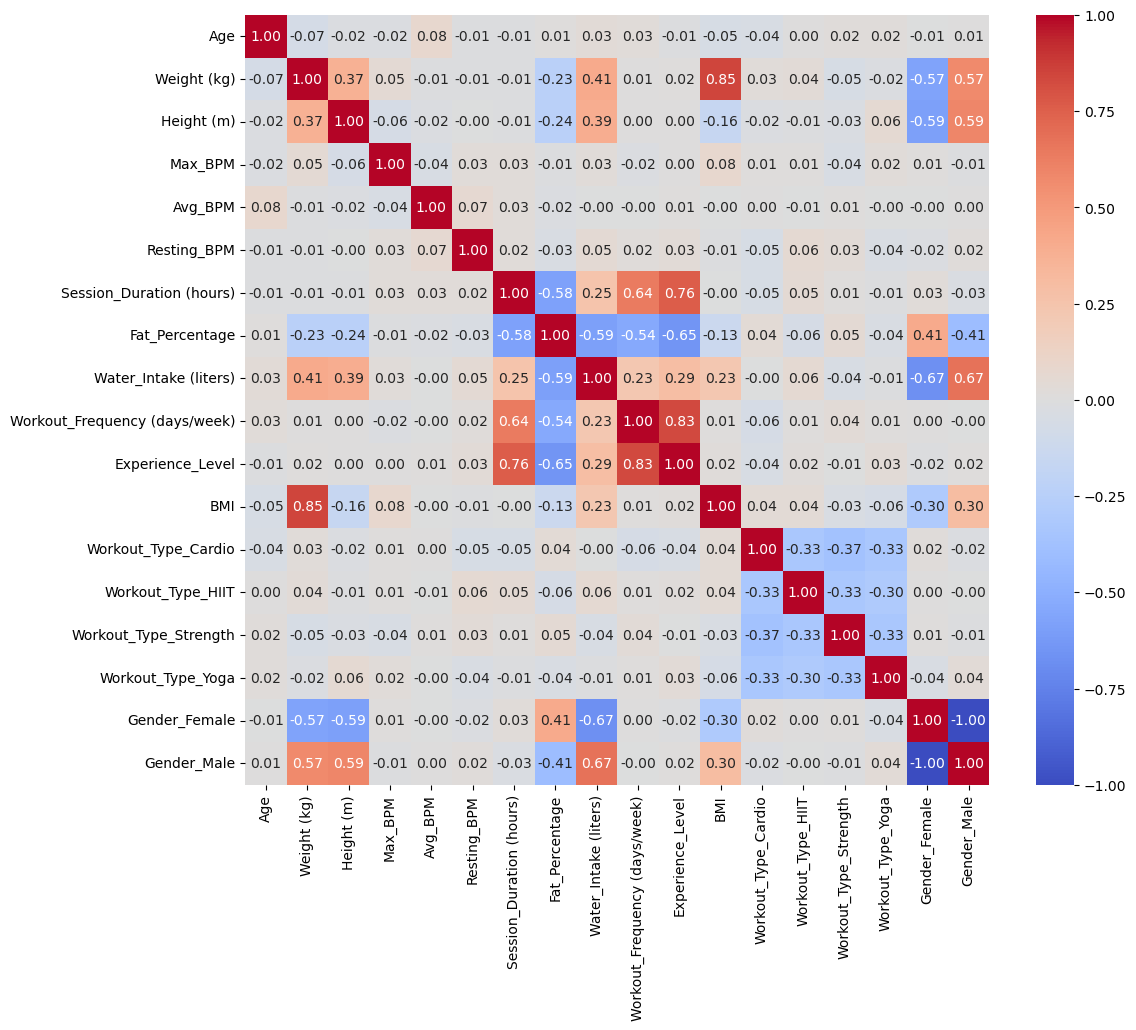

In [61]:
plt.figure(figsize=(12, 10))
sns.heatmap(df_corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

In [62]:
y_test - y_pred

199     22.042528
538     30.415662
174   -126.840868
464    255.286697
66     151.218135
          ...    
578    -80.689982
327    -78.864189
878    -63.318247
849     43.471865
801    221.834039
Name: Calories_Burned, Length: 195, dtype: float64

In [64]:
residuals.abs().mean()

np.float64(95.03480033445551)

In [65]:
from sklearn.metrics import mean_absolute_error

In [66]:
mean_absolute_error(y_test, y_pred)

95.03480033445551

In [67]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error

In [68]:
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

In [69]:
print(f"MSE: {mse}")
print(f'RMSE: {rmse}')

MSE: 15287.364950324056
RMSE: 123.64208405847928


In [70]:
np.sqrt(mse)

np.float64(123.64208405847928)

In [72]:
(residuals ** 2).mean()

np.float64(15287.364950324056)

In [73]:
from sklearn.metrics import mean_absolute_percentage_error

In [75]:
mape = mean_absolute_percentage_error(y_test, y_pred)
print(f"MAPE: {mape}")

MAPE: 0.10265685195248557


In [ ]:
mape * 100 # Erro percentual médio de 10%

10.265685195248556

In [77]:
from sklearn.metrics import r2_score

In [78]:
r2 = r2_score(y_test, y_pred)
print(f"R2: {r2}")

R2: 0.8167532484064801


## Novo Case

In [79]:
import pandas as pd

In [81]:
df_airplane = pd.read_csv('Datasets/airplane_price_dataset.csv')

In [82]:
column_names = [ 
    "Modelo", 
    "Ano de Produção", 
    "Número de Motores", 
    "Tipo de motor", 
    "Capacidade", 
    "Autonomia (km)", 
    "Consumo de Combustível (L/hora)", 
    "Custo de Manutenção ($)",
    "Idade",
    "Região de Vendas",
    "Preço ($)" 
]

In [83]:
df_airplane.columns = column_names

In [84]:
df_airplane.shape

(12377, 11)

In [ ]:
df_airplane.head()

,Modelo,Ano de Produção,Número de Motores,Tipo de motor,Capacidade,Autonomia (km),Consumo de Combustível (L/hora),Custo de Manutenção ($),Idade,Região de Vendas,Preço ($)
0,Bombardier CRJ200,1987,2,Turbofan,50,3000,14.36,2185.43,36,Asya,1.285708e+07
1,Bombardier CRJ200,1997,2,Turbofan,50,3000,4.03,1202.08,26,Avrupa,1.391406e+07
2,Airbus A320,1988,2,Turbofan,180,6300,13.26,761.38,35,Avustralya,9.073570e+07
3,Boeing 737,2023,2,Turbofan,162,5700,14.61,592.63,0,Avustralya,1.366597e+08
4,Cessna 172,1985,1,Piston,4,1285,18.49,4245.99,38,Güney Amerika,2.037981e+05


In [86]:
target = "Preço ($)"

In [87]:
df_airplane[target].describe()

count    1.237700e+04
mean     1.988336e+08
std      2.290392e+08
min      1.458148e+05
25%      1.409681e+07
50%      8.392191e+07
75%      3.843239e+08
max      9.782132e+08
Name: Preço ($), dtype: float64

<Axes: ylabel='Frequency'>

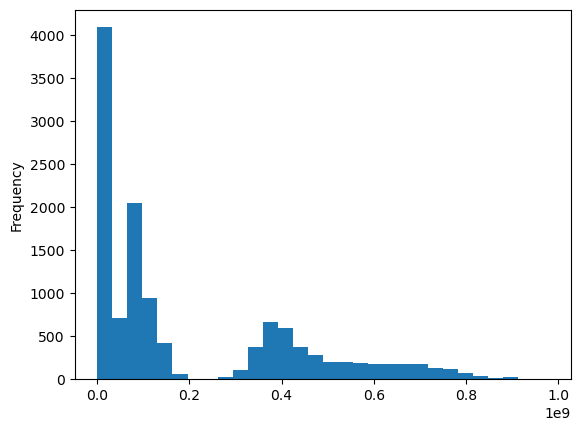

In [88]:
df_airplane[target].plot(kind="hist", bins=30)

In [89]:
df_airplane[target] = df_airplane[target] / 1000000

In [90]:
X = df_airplane.drop(target, axis=1)
y = df_airplane[target]

In [91]:
X.select_dtypes("object").describe()

,Modelo,Tipo de motor,Região de Vendas
count,12377,12377,12377
unique,6,2,6
top,Boeing 737,Turbofan,Afrika
freq,2121,10338,2171


In [99]:
categorical_features = ["Modelo", "Tipo de motor", "Região de Vendas"]

In [100]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [101]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
encoder.fit(X_train[categorical_features])

X_train_categorical_columns = encoder.transform(X_train[categorical_features])
X_test_categorical_columns = encoder.transform(X_test[categorical_features])

X_train = pd.concat([X_train.drop(categorical_features, axis=1), X_train_categorical_columns], axis=1)
X_test = pd.concat([X_test.drop(categorical_features, axis=1), X_test_categorical_columns], axis=1)

In [102]:
X_train.head()

,Ano de Produção,Número de Motores,Capacidade,Autonomia (km),Consumo de Combustível (L/hora),Custo de Manutenção ($),Idade,Modelo_Airbus A320,Modelo_Airbus A350,Modelo_Boeing 737,...,Modelo_Bombardier CRJ200,Modelo_Cessna 172,Tipo de motor_Piston,Tipo de motor_Turbofan,Região de Vendas_Afrika,Região de Vendas_Asya,Região de Vendas_Avrupa,Região de Vendas_Avustralya,Região de Vendas_Güney Amerika,Região de Vendas_Kuzey Amerika
123,1988,2,350,14800,9.45,4777.73,35,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
7033,1986,2,162,5700,3.43,516.27,37,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1952,2017,2,396,15600,13.86,4709.85,6,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
10599,1982,2,180,6300,3.42,2721.65,41,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
6131,1989,2,50,3000,6.16,1974.45,34,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


In [103]:
from sklearn.tree import DecisionTreeRegressor

In [106]:
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [105]:
def regression_report(y_true, y_pred): 
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return pd.Series({
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    })

y_pred = model.predict(X_test)
regression_report(y_test, y_pred)

MAE       23.093169
MSE     1970.238594
RMSE      44.387370
R2         0.963141
dtype: float64

In [107]:
regression_report(y_test, y_pred)

MAE       23.093169
MSE     1970.238594
RMSE      44.387370
R2         0.963141
dtype: float64

## KNN